In [1]:
import polars as pl
import pandas as pd
import pickle
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path
from datetime import date

### Compare MST real - null model

In [25]:
# font size
ticks_size = 19
labels_size = 30
legend_size = 15

#### Total

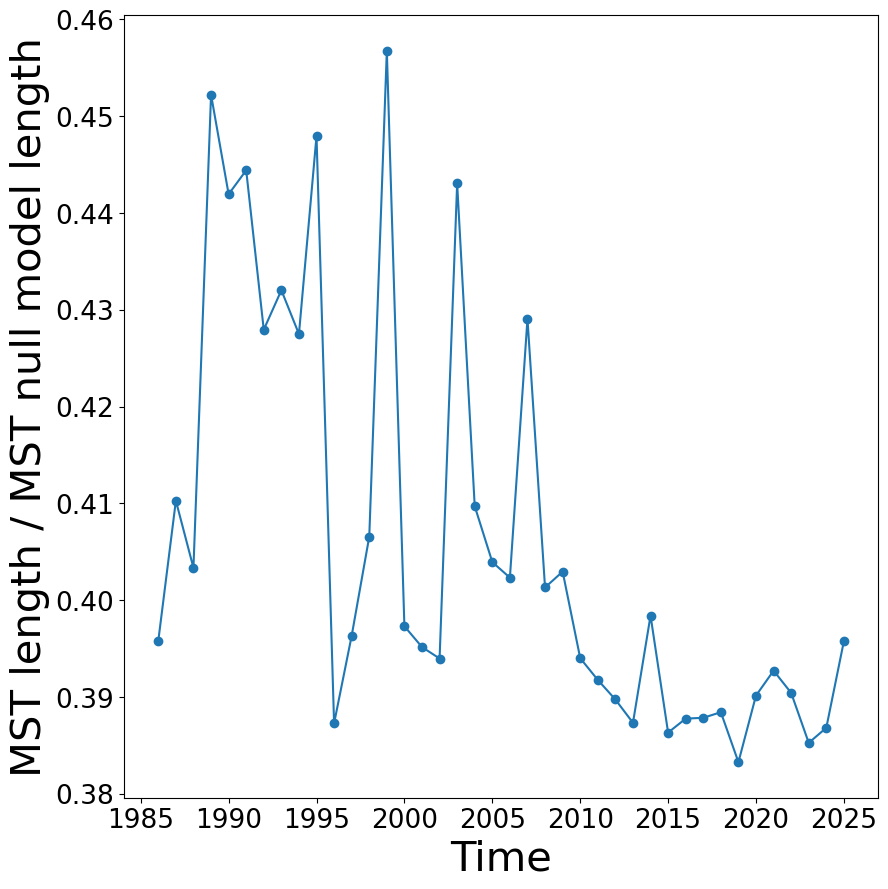

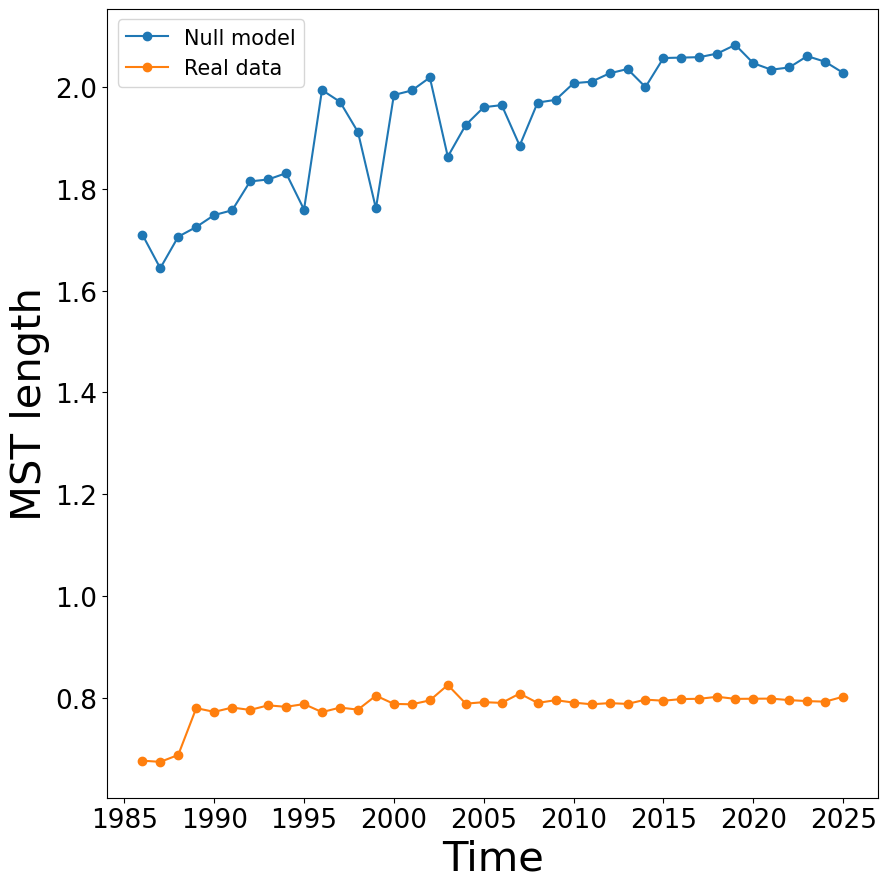

In [26]:
# type of embeddings: emb, red_emb_umap, red_emb_pca
type_emb = 'emb'
# type emb: emb, red_emb
emb = 'emb'
# dimensionality -> for reduced embeddings
components = 112
# type of sampling: convex_hull or bounding_box
null_type = 'bounding_box'
# windows
window = 12 # number of months
# step
step = 12 # number of months

# real dir
real_dir_window = 'min spanning tree/knn norm12 year_months step 12 window/tot emb/'
# null model dir
null_dir_window = 'min spanning tree/knn null model bounding_box norm tot emb/window_' + str(window) + '_step_' + str(step) + '/'
# comparison dir
ratio_dir = 'min spanning tree/mst vs null model norm/embeddings tot ' + null_type + ' norm/'

# window tot
window_list_file = open(real_dir_window + 'windows time tot_' + emb + '_list/windows.pkl', 'rb')
#window_list_file = open('min spanning tree/knn norm12 year_months step 12 window/tot emb/windows time tot_emb_list/windows.pkl')
window_list = pickle.load(window_list_file)
window_tot_real_file = open(real_dir_window + 'mst len window tot_' + emb + '_list/mst_len.pkl', 'rb')
window_tot_real = pickle.load(window_tot_real_file)
window_tot_null_file = open(null_dir_window + 'mst len window tot_' + emb + '_list/mst_len_mean.pkl', 'rb')
window_tot_null = pickle.load(window_tot_null_file)
ratio_null_real_window = np.array(window_tot_real) / np.array(window_tot_null)

# plot ratio
fig,ax = plt.subplots(figsize = (9,9))
# remove first 3 windows bcs too few points
ax.plot(window_list[3:], ratio_null_real_window[3:], '-o')
ax.tick_params(axis='both', which='major', labelsize=ticks_size)
ax.set_xlabel('Time', fontsize=labels_size)
ax.set_ylabel('MST length / MST null model length', fontsize=labels_size)
plt.tight_layout()
plt.show()
output_plot_dir = Path(ratio_dir + 'window tot_' + str(window) + '_step_' + str(step))
output_plot_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(ratio_dir + 'window tot_' + str(window) + '_step_' + str(step) + '/ratio window tot_' + emb + '_NO_OUT.png')


# plot together
fig,ax = plt.subplots(figsize = (9,9))
# remove first 3 windows bcs too few points
ax.plot(window_list[3:], window_tot_null[3:], '-o', label='Null model')
ax.plot(window_list[3:], window_tot_real[3:], '-o', label='Real data')
#ax.plot(window_list, window_tot_null, '-o', label='Null model')
#ax.plot(window_list, window_tot_real, '-o', label='Real data')
ax.tick_params(axis='both', which='major', labelsize=ticks_size)#16
ax.set_xlabel('Time', fontsize=labels_size)#20
breakpoint()
ax.set_ylabel('MST length', fontsize=labels_size)
ax.legend(fontsize=legend_size)
plt.tight_layout()
plt.show()
'''output_plot_dir = Path(ratio_dir + 'window tot')
output_plot_dir.mkdir(parents=True, exist_ok=True)'''
fig.savefig(ratio_dir + 'window tot_' + str(window) + '_step_' + str(step) + '/window null vs real_' + emb + '_NO_OUT.png')
#fig.savefig(ratio_dir + 'window tot/window null vs real_' + emb + '.png')


#### Cumulative

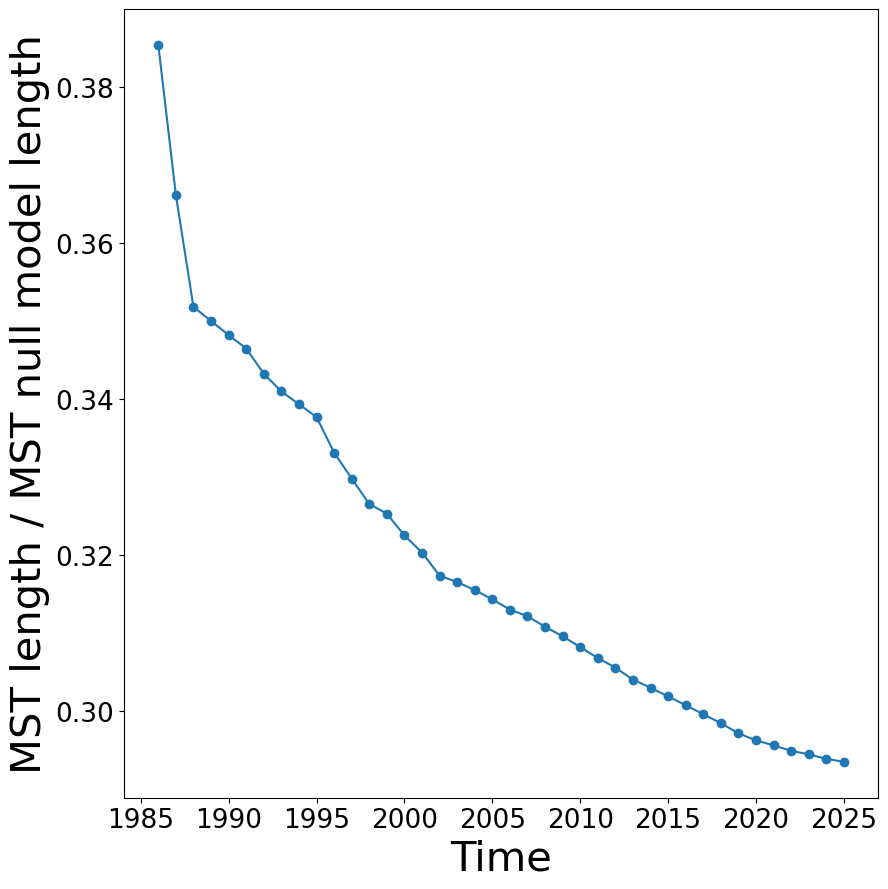

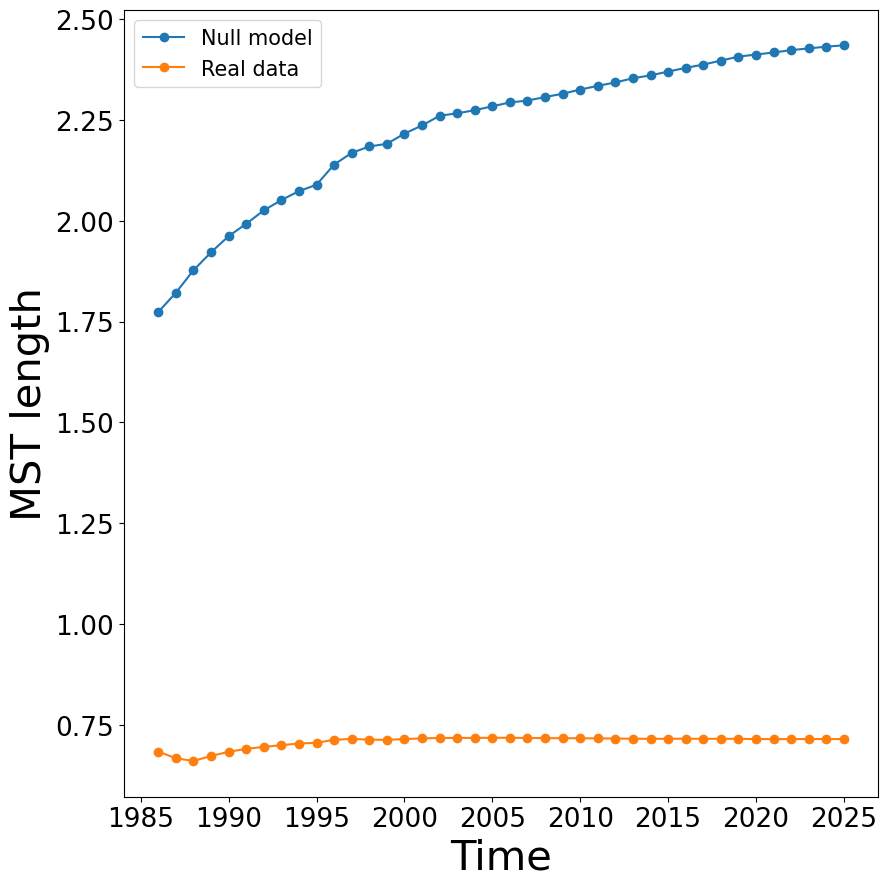

In [27]:
# type of embeddings: emb, red_emb_umap, red_emb_pca
type_emb = 'emb'
# type emb: emb, red_emb
emb = 'emb'
# dimensionality -> for reduced embeddings
components = 112
# type of sampling: convex_hull or bounding_box
null_type = 'bounding_box'
# windows
window = 12 # number of months
# step
step = 12 # number of months

# real dir
real_dir_window = 'min spanning tree/knn norm12 year_months step 12 window/tot emb NORM CUMULATIVE/'
# real dir fp
#real_dir_fp = 'min spanning tree/FP/knn norm tot emb/'
# null model dir
null_dir_window = 'min spanning tree/knn null model bounding_box norm tot emb CUMULATIVE/window_' + str(window) + '_step_' + str(step) + '/'
# null model dir fp
#null_dir_fp = 'min spanning tree/knn null model ' + null_type + ' norm tot emb/'
# comparison dir
ratio_dir = 'min spanning tree/mst vs null model norm/embeddings tot bounding_box CUMULATIVE/' + null_type + ' norm/'

# window tot
window_list_file = open(real_dir_window + 'windows time tot_' + emb + '_list/windows.pkl', 'rb')
window_list = pickle.load(window_list_file)
window_tot_real_file = open(real_dir_window + 'mst len window tot_' + emb + '_list/mst_len.pkl', 'rb')
window_tot_real = pickle.load(window_tot_real_file)
window_tot_null_file = open(null_dir_window + 'mst len window tot_' + emb + '_list/mst_len_mean.pkl', 'rb')
window_tot_null = pickle.load(window_tot_null_file)
ratio_null_real_window = np.array(window_tot_real) / np.array(window_tot_null)

# plot ratio
fig,ax = plt.subplots(figsize = (9,9))
# remove first 3 windows bcs too few points
ax.plot(window_list[3:], ratio_null_real_window[3:], '-o')
#ax.plot(window_list, ratio_null_real_window, '-o')
ax.tick_params(axis='both', which='major', labelsize=ticks_size)
ax.set_xlabel('Time', fontsize=labels_size)
ax.set_ylabel('MST length / MST null model length', fontsize=labels_size)
plt.tight_layout()
plt.show()
fig.savefig(ratio_dir + 'window tot_' + str(window) + '_step_' + str(step) + '/ratio window tot_' + emb + '_NO_OUT.png')


# plot together
fig,ax = plt.subplots(figsize = (9,9))
# remove first 3 windows bcs too few points
ax.plot(window_list[3:], window_tot_null[3:], '-o', label='Null model')
ax.plot(window_list[3:], window_tot_real[3:], '-o', label='Real data')
#ax.plot(window_list, window_tot_null, '-o', label='Null model')
#ax.plot(window_list, window_tot_real, '-o', label='Real data')
ax.tick_params(axis='both', which='major', labelsize=ticks_size)
ax.set_xlabel('Time', fontsize=labels_size)
breakpoint()
ax.set_ylabel('MST length', fontsize=labels_size)
ax.legend(fontsize=legend_size)
plt.tight_layout()
plt.show()
output_plot_dir = Path(ratio_dir + 'window tot')
output_plot_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(ratio_dir + 'window tot_' + str(window) + '_step_' + str(step) + '/window null vs real_' + emb + '_NO_OUT.png')
#fig.savefig(ratio_dir + 'window tot/window null VS real_' + emb + '.png')